In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm

font_path = "figutils/Helvetica.ttf"
fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
print(font_name)

plt.rcParams["font.family"] = font_name

/home/hsh/miniconda3/envs/hsh/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helvetica


In [2]:
# =============================================================================
# Configuration
# =============================================================================
DEFAULT_SIZE_LEVELS = {
    'Low':  {'thresh': 1_000,        'size': 30,  'label': '< 1k'},
    'Mid':  {'thresh': 50_000,       'size': 100, 'label': '1k – 50k'},
    'High': {'thresh': float('inf'), 'size': 450, 'label': '> 50k'},
}

# =============================================================================
# Data Loading
# =============================================================================

def load_token_frequencies(data_bin_path):
    """
    Compute per-token frequencies from a binary training dataset.

    Returns
    -------
    dict : token_id → count
    """
    COMPOSITE_DTYPE = np.dtype([
        ('ID',    np.uint32),
        ('AGE',   np.uint32),
        ('DATA',  np.uint32),
        ('SHIFT', np.uint32),
        ('TOTAL', np.uint32),
    ])

    print(f"[INFO] Computing token frequencies from: {data_bin_path}")
    if not os.path.exists(data_bin_path):
        print("[WARN] Dataset file not found. Returning empty counts.")
        return {}

    data_raw = np.fromfile(data_bin_path, dtype=COMPOSITE_DTYPE)
    shifted_tokens = data_raw['DATA'] + 1
    unique, counts = np.unique(shifted_tokens, return_counts=True)
    token_counts = dict(zip(unique.tolist(), counts.tolist()))
    print(f"[OK]  {len(token_counts)} unique tokens")
    return token_counts


def load_chapter_metadata(csv_path, start_token_id=22):
    """
    Load token-to-chapter metadata CSV.

    Returns
    -------
    token_meta : dict  (token_id → {name, chapter_short, color, …})
    legend_info : pd.DataFrame  (unique chapter_short + color)
    """
    print(f"[INFO] Loading chapter metadata from: {csv_path}")
    df = pd.read_csv(csv_path, header=None)

    if df.shape[1] == 6:
        df.columns = ['raw_idx', 'name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    elif df.shape[1] == 5:
        df.columns = ['name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    else:
        raise ValueError(f"Unexpected column count: {df.shape[1]}")

    df['token_id'] = pd.to_numeric(df['token_id'], errors='coerce')
    df = df.dropna(subset=['token_id'])
    df['token_id'] = df['token_id'].astype(int)

    filtered = df[df['token_id'] >= start_token_id].copy()
    token_meta = filtered.set_index('token_id').to_dict('index')
    legend_info = filtered[['chapter_short', 'color']].drop_duplicates()

    return token_meta, legend_info

# =============================================================================
# Embedding Extraction
# =============================================================================

def get_embeddings(ckpt_path, token_meta):
    """
    Extract token embeddings from a trained checkpoint.

    Returns
    -------
    embeddings : np.ndarray  (n_tokens, n_embd)
    valid_token_ids : list[int]
    """
    from figutils.common import load_model

    print(f"[INFO] Loading embeddings from {ckpt_path}")
    model, ckpt = load_model(ckpt_path, device='cpu')

    full_emb = model.composite_emb.data_emb.weight.detach().numpy()
    valid_ids = sorted(token_meta.keys())
    return full_emb[valid_ids], valid_ids


# =============================================================================
# UMAP & Plotting
# =============================================================================

def run_umap(embeddings, n_neighbors=30, min_dist=0.05, metric='cosine'):
    """Run UMAP dimensionality reduction → (N, 2) array."""
    print("[INFO] Running UMAP...")
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, min_dist=min_dist,
        metric=metric, random_state=45,
    )
    return reducer.fit_transform(embeddings)

In [ ]:
# from figutils.umap_viz import (
#     load_token_frequencies, load_chapter_metadata,
#     get_embeddings, run_umap, draw_umap_plot
# )

CKPT_PATH   = '../out/0403/2040/ckpt.pt'
LABELS_PATH = '../../data/labels_chapter.csv'
TRAIN_BIN   = '../../data/kr_val.bin'

# 라벨링할 토큰 ID
# TARGET_IDS = [224, 225, 1285, 1286, 1289]#[224,1278,1279,1280,1281,1282,1283,1284,1285,1286,1287,1288,1289 ]  
#[223,224,225,226,227,508,879,1177, 1278,1279,1280,1281,1282,1283,1284,1285,1286,1287,1288,1289]

# 데이터 준비
token_counts = load_token_frequencies(TRAIN_BIN)
token_meta, legend_info = load_chapter_metadata(LABELS_PATH)
embeddings, valid_ids = get_embeddings(CKPT_PATH, token_meta)
umap_2d = run_umap(embeddings, n_neighbors=15, min_dist=0.1)

[INFO] Computing token frequencies from: ../../data/kr_val.bin
[OK]  1053 unique tokens
[INFO] Loading chapter metadata from: ../../data/labels_chapter.csv
[INFO] Loading embeddings from ../out/0402/2357/ckpt.pt
[INFO] Loading model from ../out/0402/2357/ckpt.pt → cpu
[INFO] Detected BinaryChangeHead → using model_v2
[WARN] Skipped unknown config fields: {'shift_focal_gamma', 'total_max_value', 'shift_na_raw_token', 'shift_dice_weight', 'total_min_value', 'shift_class_weights', 'separate_shift_na_from_padding', 'total_vocab_size', 'use_teacher_forcing_drug_cond', 'shift_loss_type', 'loss_weight_total', 'drug_token_only_shift', 'shift_vocab_size', 'data_label_smoothing', 'total_log_transform', 'num_shift_classes', 'shift_ignore_index', 'loss_weight_shift', 'drug_token_only_total'}
[WARN] Missing keys (initialized randomly): ['composite_emb.dose_emb.weight', 'composite_emb.dur_emb.weight', 'composite_emb.dose_value_proj.0.weight', 'composite_emb.dose_value_proj.0.bias', 'composite_emb.do

/home/hsh/miniconda3/envs/hsh/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
def draw_umap_plot(embedding_2d, valid_token_ids, token_meta,
                   token_counts, legend_info,
                   target_label_ids=None, size_levels=None,
                   figsize=(12, 8), save_path=None):

    if size_levels is None:
        size_levels = DEFAULT_SIZE_LEVELS

    print("[INFO] Rendering UMAP scatter plot...")

    df = pd.DataFrame(embedding_2d, columns=['x', 'y'])
    df['token_id'] = valid_token_ids
    df['color'] = [token_meta[t]['color'] for t in valid_token_ids]
    df['name'] = [token_meta[t]['name'] for t in valid_token_ids]

    sizes = []
    for t in valid_token_ids:
        c = token_counts.get(t, 0)
        if c < size_levels['Low']['thresh']:
            sizes.append(size_levels['Low']['size'])
        elif c < size_levels['Mid']['thresh']:
            sizes.append(size_levels['Mid']['size'])
        else:
            sizes.append(size_levels['High']['size'])
    df['size'] = sizes

    # Main plot + dedicated legend axis
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[4.7, 1.5], wspace=0.02)

    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])
    ax_leg.axis("off")

    ax.scatter(
        df['x'], df['y'],
        c=df['color'],
        s=df['size'],
        alpha=0.8,
        edgecolors='white',
        linewidth=0.3
    )

    # Annotate selected tokens
    if target_label_ids:
        texts = []
        for _, row in df.iterrows():
            if int(row['token_id']) in target_label_ids:
                t = ax.text(
                    row['x'], row['y'],
                    f"{row['name']} ({int(row['token_id'])})",
                    fontsize=10, fontweight='bold', color='black'
                )
                texts.append(t)
        try:
            from adjustText import adjust_text
            adjust_text(
                texts,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                ax=ax
            )
        except ImportError:
            pass

    # ---------------------------
    # Legend 1: chapter legend
    # ---------------------------
    patches = [
        mlines.Line2D(
            [], [], linestyle='None',
            marker='o',
            markerfacecolor=r['color'],
            markeredgecolor='black',
            markeredgewidth=0.4,
            markersize=8,
            label=r['chapter_short']
        )
        for _, r in legend_info.iterrows()
    ]

    leg1 = ax_leg.legend(
        handles=patches,
        loc='upper left',
        bbox_to_anchor=(0.0, 0.9),
        fontsize=9,
        frameon=True,
        borderaxespad=0.0,
        # linewidth=0.3,
        ncol=1,
        handletextpad=0.4 
    )
    ax_leg.add_artist(leg1)

    # Draw once to calculate legend size
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = leg1.get_window_extent(renderer=renderer)

    # Convert legend bbox to ax_leg axes coordinates
    bbox_axes = bbox.transformed(ax_leg.transAxes.inverted())

    # ---------------------------
    # Legend 2: frequency legend
    # place directly below chapter legend
    # ---------------------------
    label_size_levels = {
        'Low':  {'thresh': 1_000,        'size': 30,  'label': '< 1k'},
        'Mid':  {'thresh': 50_000,       'size': 100, 'label': '1k – 50k'},
        'High': {'thresh': float('inf'), 'size': 250, 'label': '> 50k'},
    }
 
    size_handles = [
        mlines.Line2D(
            [], [],
            color='black',
            marker='o',
            # linewidth=0.2,
            linestyle='None',
            markerfacecolor='gray',
            alpha=0.7,
            markersize=np.sqrt(label_size_levels[lv]['size']),
            label=label_size_levels[lv]['label']
        )
        for lv in ('Low', 'Mid', 'High')
    ]

    freq_y = bbox_axes.y0 - 0.04  # small gap below chapter legend

    ax_leg.legend(
        handles=size_handles,
        loc='upper left',
        bbox_to_anchor=(0.0, freq_y),
        title='Frequency',
        title_fontsize=9,
        fontsize=9,
        frameon=False,
        borderaxespad=0.0,
        labelspacing=1.02
    )

    # Clean main axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[OK]  Saved → {save_path}")

    return fig

In [5]:
desired_order = [
    'I. Infectious Diseases',
    'II. Neoplasms',
    'III. Blood & Immune Disorders',
    'IV. Metabolic Diseases',
    'V. Mental Disorders',
    'VI. Nervous System Diseases',
    'VII. Eye Diseases',
    'VIII. Ear Diseases',
    'IX. Circulatory Diseases',
    'X. Respiratory Diseases',
    'XI. Digestive Diseases',
    'XII. Skin Diseases',
    'XIII. Musculoskeletal Diseases',
    'XIV. Genitourinary Diseases',
    'XV. Pregnancy & Childbirth',
    'XVI. Perinatal Conditions',
    'XVII. Congenital Abnormalities',
    'XX. Diabetes drugs',
    'Death'
]

legend_info['chapter_short'] = pd.Categorical(
    legend_info['chapter_short'],
    categories=desired_order,
    ordered=True
)

legend_info = legend_info.sort_values('chapter_short').reset_index(drop=True)
legend_info

,chapter_short,color
0,I. Infectious Diseases,#98df8a
1,II. Neoplasms,#ff7f0e
2,III. Blood & Immune Disorders,#ff9896
3,IV. Metabolic Diseases,#2ca02c
4,V. Mental Disorders,#9edae5
5,VI. Nervous System Diseases,#7f7f7f
6,VII. Eye Diseases,#aec7e8
7,VIII. Ear Diseases,#dbdb8d
8,IX. Circulatory Diseases,#d62728
9,X. Respiratory Diseases,#17becf


In [6]:
legend_info.loc[0, 'color'] = '#91c987' ### I. Infectious Diseases
legend_info.loc[1, 'color'] = '#ec713f' ### II. Neoplasms
legend_info.loc[2, 'color'] = '#dd5752' ### III. Blood & Immune Disorders
legend_info.loc[3, 'color'] = '#4f7951' ### IV. Metabolic Diseases
legend_info.loc[4, 'color'] = '#90c0c2' ### V. Mental Disorders
legend_info.loc[5, 'color'] = '#87776a' ### VI. Nervous System Diseases
# legend_info.loc[6, 'color'] = '#87776a' ### VII. Eye Diseases
legend_info.loc[7, 'color'] = '#e6c186' ### VIII. Ear Diseases	
legend_info.loc[8, 'color'] = '#c34a54' ### IX. Circulatory Diseases
legend_info.loc[9, 'color'] = '#567797' ### X. Respiratory Diseases
legend_info.loc[10, 'color'] = '#6b512a' ### XI. Digestive Diseases
# legend_info.loc[11, 'color'] = '#' ### XII. Skin Diseases
legend_info.loc[12, 'color'] = '#2964b8' ### XIII. Musculoskeletal Diseases
legend_info.loc[13, 'color'] = '#f7b141' ### XIV. Genitourinary Diseases
legend_info.loc[14, 'color'] = '#e45c88' ### XV. Pregnancy & Childbirth
# legend_info.loc[15, 'color'] = '#d08b32' ### XVI. Perinatal Conditions
# legend_info.loc[16, 'color'] = '#e45c88' ### XVII. Congenital Abnormalities
# legend_info['chapter_short'] = legend_info['chapter_short'].cat.add_categories(['Medication for Diabetes'])
# legend_info.loc[17, 'chapter_short'] = 'Medication for Diabetes'
# legend_info.loc[17, 'color'] = '#f7b141' ### Medication for Diabetes
legend_info.loc[18, 'color'] = '#1d1f20' ### Death

for k, v in token_meta.items():
    if v['color'] == '#98df8a':
        token_meta[k]['color'] = "#91c987"
    elif v['color'] == '#ff7f0e':
        token_meta[k]['color'] = '#ec713f'
    elif v['color'] == '#ff9896':
        token_meta[k]['color'] = "#dd5752"
    elif v['color'] == '#2ca02c':
        token_meta[k]['color'] = "#4f7951"
    elif v['color'] == '#9edae5':
        token_meta[k]['color'] = '#90c0c2'
    elif v['color'] == '#7f7f7f':
        token_meta[k]['color'] = '#87776a'
        
    elif v['color'] == '#dbdb8d':
        token_meta[k]['color'] = '#e6c186'
    elif v['color'] == '#d62728':
        token_meta[k]['color'] = '#c34a54'
    elif v['color'] == '#17becf':
        token_meta[k]['color'] = '#567797'
    elif v['color'] == '#1f77b4':
        token_meta[k]['color'] = '#2964b8'
    elif v['color'] == '#8c564b':
        token_meta[k]['color'] = '#6b512a'
    elif v['color'] == '#ffbb78':
        token_meta[k]['color'] = '#f7b141'
    elif v['color'] == '#e377c2':
        token_meta[k]['color'] = '#e45c88'
    # elif v['color'] == '#FFFF00':
    #     token_meta[k]['color'] = '#f7b141'
    elif v['color'] == '#000a35':
        token_meta[k]['color'] = '#1d1f20'
        

In [7]:
legend_info

,chapter_short,color
0,I. Infectious Diseases,#91c987
1,II. Neoplasms,#ec713f
2,III. Blood & Immune Disorders,#dd5752
3,IV. Metabolic Diseases,#4f7951
4,V. Mental Disorders,#90c0c2
5,VI. Nervous System Diseases,#87776a
6,VII. Eye Diseases,#aec7e8
7,VIII. Ear Diseases,#e6c186
8,IX. Circulatory Diseases,#c34a54
9,X. Respiratory Diseases,#567797


[INFO] Rendering UMAP scatter plot...


/tmp/ipykernel_2130020/2622505600.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


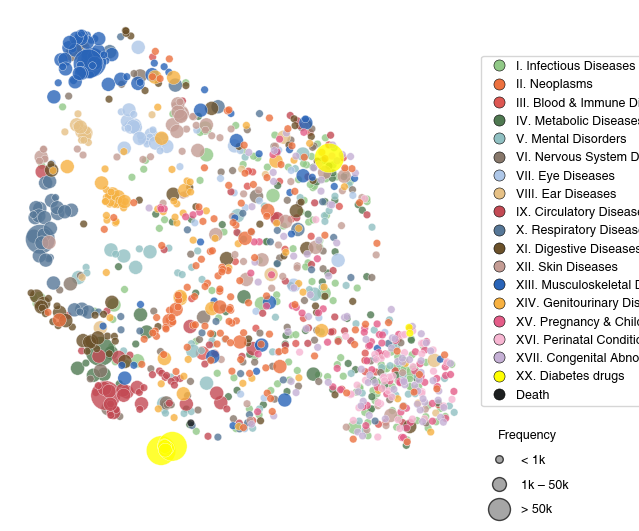

In [11]:
TARGET_IDS = [1279,1280,1281,1282,1283,1284,1285,1286,1287,1288,1289]

fig = draw_umap_plot(
    umap_2d, valid_ids, token_meta, token_counts, legend_info,
    # target_label_ids=TARGET_IDS,
    figsize=(8,6)
)
# fig.savefig('umap_embedding.png', dpi=300, bbox_inches='tight')  # to save
plt.show()

In [9]:
import numpy as np
import pandas as pd

df = pd.DataFrame(umap_2d, columns=['x', 'y'])
df['token_id'] = valid_ids
df['name'] = [token_meta[t]['name'] for t in valid_ids]

target_id = 1288
target_row = df[df['token_id'] == target_id].iloc[0]

df['dist_to_glp1'] = np.sqrt((df['x'] - target_row['x'])**2 + (df['y'] - target_row['y'])**2)

near_glp1 = (
    df[df['token_id'] != target_id]
    .sort_values('dist_to_glp1')
    [['token_id', 'name', 'dist_to_glp1']]
    .head(15)
)

print(near_glp1.to_string(index=False))

 token_id                                                                   name  dist_to_glp1
      229                   E16 Other disorders of pancreatic internal secretion      0.031561
      623                              J69 Pneumonitis due to solids and liquids      0.043531
       55                                                  A41 Other septicaemia      0.156184
      290 F05 Delirium, not induced by alcohol and other psychoactive substances      0.170194
      287                    F02 Dementia in other diseases classified elsewhere      0.183100
      282        E87 Other disorders of fluid, electrolyte and acid-base balance      0.221429
      422                                           G93 Other disorders of brain      0.228476
      547                        I62 Other nontraumatic intracranial haemorrhage      0.291865
      878                                                N17 Acute renal failure      0.297957
      538                                         